In [ ]:
import numpy as np
import torch
import os
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# -------------------------------
# 1. Define ODE system (12 vars)
# -------------------------------
def ode_system(t, y, params):
    ATP, P2X7, P2X7s, Ca_cyt, Ca_ext, MAP3K, MAP3Ks, JNK, JNKs, cJun, cJuns, PTC = y
    k1, k_1, k_deg, k_in, k_out, k2, k_2, k_dp1, k3, k_3, k_dp2, k4, k_4, k_dp3, k_prolif, k_decay = params

    dATP   = -k1 * ATP * P2X7 + k_1 * P2X7s - k_deg * ATP
    dP2X7  = -k1 * ATP * P2X7 + k_1 * P2X7s
    dP2X7s = k1 * ATP * P2X7 - k_1 * P2X7s

    dCa_cyt = k_in * P2X7s * (Ca_ext - Ca_cyt) - k_out * Ca_cyt - k2 * Ca_cyt * MAP3K + k_2 * MAP3Ks
    dCa_ext = -k_in * P2X7s * (Ca_ext - Ca_cyt)

    dMAP3Ks = k2 * Ca_cyt * MAP3K - k_2 * MAP3Ks - k_dp1 * MAP3Ks - k3 * MAP3Ks * JNK + k_3 * JNKs
    dMAP3K  = -k2 * Ca_cyt * MAP3K + k_2 * MAP3Ks + k_dp1 * MAP3Ks

    dJNKs = k3 * MAP3Ks * JNK - k_3 * JNKs - k_dp2 * JNKs - k4 * JNKs * cJun + k_4 * cJuns
    dJNK  = -k3 * MAP3Ks * JNK + k_3 * JNKs + k_dp2 * JNKs

    dcJuns = k4 * JNKs * cJun - k_4 * cJuns - k_dp3 * cJuns - k_prolif * cJuns + k_decay * PTC
    dcJun  = -k4 * JNKs * cJun + k_4 * cJuns + k_dp3 * cJuns

    dPTC = k_prolif * cJuns - k_decay * PTC

    return np.array([dATP, dP2X7, dP2X7s, dCa_cyt, dCa_ext, dMAP3K, dMAP3Ks,
                     dJNK, dJNKs, dcJun, dcJuns, dPTC])

# 2. RK4 Solver

def rk4_step(f, t, y, dt, params):
    k1 = f(t, y, params)
    k2 = f(t + dt/2, y + dt/2*k1, params)
    k3 = f(t + dt/2, y + dt/2*k2, params)
    k4 = f(t + dt, y + dt*k3, params)
    return y + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)

def solve_rk4(f, y0, t_span, dt, params):
    t0, tf = t_span
    t_values = np.arange(t0, tf+dt, dt)
    y_values = np.zeros((len(t_values), len(y0)))
    y = y0.copy()
    for i, t in enumerate(t_values):
        y_values[i] = y
        y = rk4_step(f, t, y, dt, params)
    return t_values, y_values


# -------------------------------
# 3. PINN Model
# -------------------------------
class PINN(nn.Module):
    def __init__(self, layers=[1, 32, 32, 12]):
        super(PINN, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers)-1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))
        self.activation = torch.tanh

    def forward(self, t):
        x = t
        for i in range(len(self.layers)-1):
            x = self.activation(self.layers[i](x))
        return self.layers[-1](x)


# -------------------------------
# 4. Train PINN with RK4 Data
# -------------------------------
def train_pinn(model, t_train, y_train, params, epochs=20000, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    t_tensor = torch.tensor(t_train, dtype=torch.float32).view(-1,1)
    y_tensor = torch.tensor(y_train, dtype=torch.float32)

    for epoch in range(epochs):
        optimizer.zero_grad()
        y_pred = model(t_tensor)

        # Data loss (RK4 fit)
        loss_data = mse(y_pred, y_tensor)

        # Physics loss (residuals)
        t_tensor.requires_grad_(True)
        y_pred_resid = model(t_tensor)
        dydt_pred = torch.autograd.grad(y_pred_resid, t_tensor,
                                        grad_outputs=torch.ones_like(y_pred_resid),
                                        retain_graph=True, create_graph=True)[0]

        # Compute residual vs ODE
        y_numpy = y_pred_resid.detach().numpy()
        t_numpy = t_tensor.detach().numpy()
        f_ode = np.array([ode_system(t_numpy[i,0], y_numpy[i], params) for i in range(len(t_numpy))])
        f_ode = torch.tensor(f_ode, dtype=torch.float32)

        loss_phys = mse(dydt_pred, f_ode)

        # Total loss
        loss = loss_data + loss_phys
        loss.backward()
        optimizer.step()

        if epoch % 1000 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

    return model


# -------------------------------
# 5. Main Simulation
# -------------------------------
if __name__ == "__main__":

    y0 = np.array([1,1,0,0.5,1,1,0,1,0,1,0,0])  # 12 variables
    params = [1,0.5,0.1,0.05,0.01,1,0.5,0.1,1,0.5,0.1,1,0.5,0.1,0.2,0.05]

    t_rk4, y_rk4 = solve_rk4(ode_system, y0, (0,10), 0.1, params)

    # Train PINN
    model = PINN()
    trained_pinn = train_pinn(model, t_rk4, y_rk4, params)

    # Predict
    t_test = torch.tensor(t_rk4, dtype=torch.float32).view(-1,1)
    y_pinn = trained_pinn(t_test).detach().numpy()



Image saved to: C:\Users\E-TEC\Downloads\comp Simulation1 GRAPH.jpg


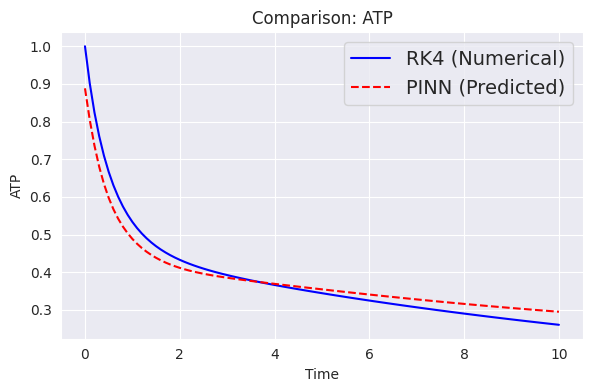

In [3]:
import matplotlib.pyplot as plt
import os
import re

# Labels for variables
labels = ['ATP'] #'P2X7', 'P2X7*', 'Ca_cyt', 'Ca_ext',
         # 'MAP3K', 'MAP3K*', 'JNK', 'JNK*', 'cJun', 'cJun*', 'PTC']

# Create output directory
os.makedirs("results", exist_ok=True)

# Function to make filenames safe
def safe_filename(name):
    return re.sub(r'[^a-zA-Z0-9_]', "_", name)

# Plot and save each variable
for i in range(1):
    plt.figure(figsize=(6,4))
    plt.plot(t_rk4, y_rk4[:, i], 'b-', label="RK4 (Numerical)")
    plt.plot(t_test.numpy(), y_pinn[:, i], 'r--', label="PINN (Predicted)")
    plt.xlabel("Time")
    plt.ylabel(labels[i])
    plt.title(f"Comparison: {labels[i]}")
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.style.use("default")   # reset to default (white background)
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.facecolor"] = "white"
    # Save the figure locally
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
file_path = os.path.join(downloads_path, "comp Simulation1 GRAPH.jpg")
plt.savefig(file_path, dpi=300)
print(f"Image saved to: {file_path}")




In [4]:
    # MAE for each variable
mae_per_var = []
for i in range(1):
    mae = mean_absolute_error(y_rk4[:, i], y_pinn[:, i])
    mae_per_var.append(mae)
    print(f"MAE for {labels[i]}: {mae:.6f}")

MAE for ATP: 0.024684


Image saved to: C:\Users\E-TEC\Downloads\comp Simulation2 GRAPH.jpg


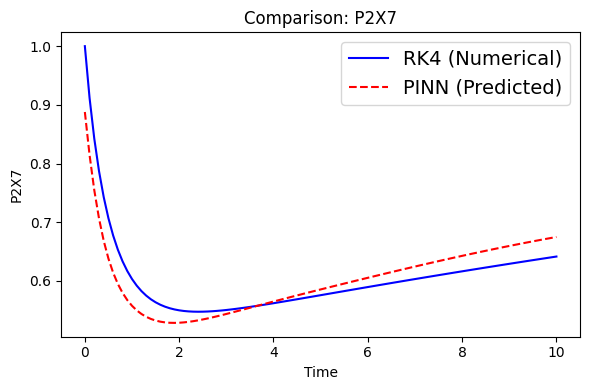

In [5]:
import matplotlib.pyplot as plt
import os
import re

# Labels for variables
labels = ['ATP', 'P2X7', 'P2X7*', 'Ca_cyt', 'Ca_ext',
          'MAP3K', 'MAP3K*', 'JNK', 'JNK*', 'cJun', 'cJun*', 'PTC']

# Create output directory
os.makedirs("results", exist_ok=True)

# Function to make filenames safe
def safe_filename(name):
    return re.sub(r'[^a-zA-Z0-9_]', "_", name)

# Plot and save each variable
for i in range(1,2):
    plt.figure(figsize=(6,4))
    plt.plot(t_rk4, y_rk4[:, i], 'b-', label="RK4 (Numerical)")
    plt.plot(t_test.numpy(), y_pinn[:, i], 'r--', label="PINN (Predicted)")
    plt.xlabel("Time")
    plt.ylabel(labels[i])
    plt.title(f"Comparison: {labels[i]}")
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.style.use("default")   # reset to default (white background)
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.facecolor"] = "white"
    # Save the figure locally
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
file_path = os.path.join(downloads_path, "comp Simulation2 GRAPH.jpg")
plt.savefig(file_path, dpi=300)
print(f"Image saved to: {file_path}")

In [6]:
    # MAE for each variable
mae_per_var = []
for i in range(1,2):
    mae = mean_absolute_error(y_rk4[:, i], y_pinn[:, i])
    mae_per_var.append(mae)
    print(f"MAE for {labels[i]}: {mae:.6f}")

MAE for P2X7: 0.024628


Image saved to: C:\Users\E-TEC\Downloads\comp Simulation3 GRAPH.jpg


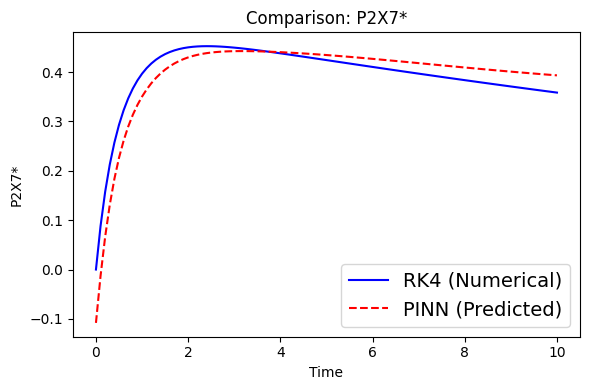

In [7]:
import matplotlib.pyplot as plt
import os
import re

# Labels for variables
labels = ['ATP', 'P2X7', 'P2X7*', 'Ca_cyt', 'Ca_ext',
          'MAP3K', 'MAP3K*', 'JNK', 'JNK*', 'cJun', 'cJun*', 'PTC']

# Create output directory
os.makedirs("results", exist_ok=True)

# Function to make filenames safe
def safe_filename(name):
    return re.sub(r'[^a-zA-Z0-9_]', "_", name)

# Plot and save each variable
for i in range(2,3):
    plt.figure(figsize=(6,4))
    plt.plot(t_rk4, y_rk4[:, i], 'b-', label="RK4 (Numerical)")
    plt.plot(t_test.numpy(), y_pinn[:, i], 'r--', label="PINN (Predicted)")
    plt.xlabel("Time")
    plt.ylabel(labels[i])
    plt.title(f"Comparison: {labels[i]}")
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.style.use("default")   # reset to default (white background)
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.facecolor"] = "white"
    # Save the figure locally
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
file_path = os.path.join(downloads_path, "comp Simulation3 GRAPH.jpg")
plt.savefig(file_path, dpi=300)
print(f"Image saved to: {file_path}")

In [8]:
    # MAE for each variable
mae_per_var = []
for i in range(2,3):
    mae = mean_absolute_error(y_rk4[:, i], y_pinn[:, i])
    mae_per_var.append(mae)
    print(f"MAE for {labels[i]}: {mae:.6f}")

MAE for P2X7*: 0.024657


Image saved to: C:\Users\E-TEC\Downloads\comp Simulation4 GRAPH.jpg


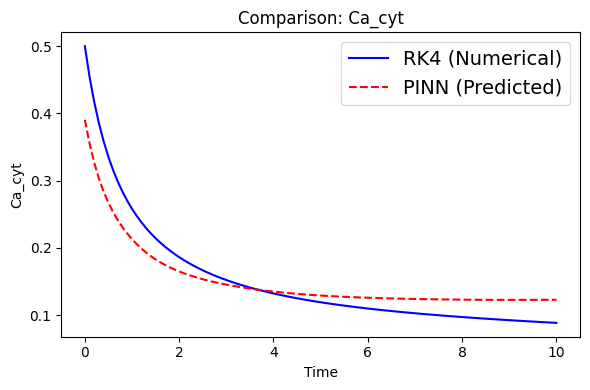

In [9]:
import matplotlib.pyplot as plt
import os
import re

# Labels for variables
labels = ['ATP', 'P2X7', 'P2X7*', 'Ca_cyt', 'Ca_ext',
          'MAP3K', 'MAP3K*', 'JNK', 'JNK*', 'cJun', 'cJun*', 'PTC']

# Create output directory
os.makedirs("results", exist_ok=True)

# Function to make filenames safe
def safe_filename(name):
    return re.sub(r'[^a-zA-Z0-9_]', "_", name)

# Plot and save each variable
for i in range(3,4):
    plt.figure(figsize=(6,4))
    plt.plot(t_rk4, y_rk4[:, i], 'b-', label="RK4 (Numerical)")
    plt.plot(t_test.numpy(), y_pinn[:, i], 'r--', label="PINN (Predicted)")
    plt.xlabel("Time")
    plt.ylabel(labels[i])
    plt.title(f"Comparison: {labels[i]}")
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.style.use("default")   # reset to default (white background)
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.facecolor"] = "white"
    # Save the figure locally
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
file_path = os.path.join(downloads_path, "comp Simulation4 GRAPH.jpg")
plt.savefig(file_path, dpi=300)
print(f"Image saved to: {file_path}")

In [10]:
    # MAE for each variable
mae_per_var = []
for i in range(3,4):
    mae = mean_absolute_error(y_rk4[:, i], y_pinn[:, i])
    mae_per_var.append(mae)
    print(f"MAE for {labels[i]}: {mae:.6f}")

MAE for Ca_cyt: 0.024648


Image saved to: C:\Users\E-TEC\Downloads\comp Simulation5 GRAPH.jpg


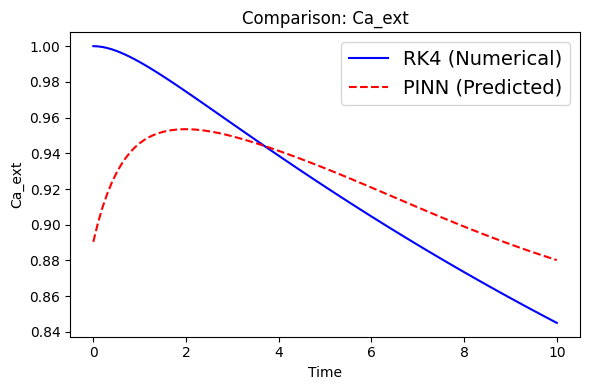

In [11]:
import matplotlib.pyplot as plt
import os
import re

# Labels for variables
labels = ['ATP', 'P2X7', 'P2X7*', 'Ca_cyt', 'Ca_ext',
          'MAP3K', 'MAP3K*', 'JNK', 'JNK*', 'cJun', 'cJun*', 'PTC']

# Create output directory
os.makedirs("results", exist_ok=True)

# Function to make filenames safe
def safe_filename(name):
    return re.sub(r'[^a-zA-Z0-9_]', "_", name)

# Plot and save each variable
for i in range(4,5):
    plt.figure(figsize=(6,4))
    plt.plot(t_rk4, y_rk4[:, i], 'b-', label="RK4 (Numerical)")
    plt.plot(t_test.numpy(), y_pinn[:, i], 'r--', label="PINN (Predicted)")
    plt.xlabel("Time")
    plt.ylabel(labels[i])
    plt.title(f"Comparison: {labels[i]}")
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.style.use("default")   # reset to default (white background)
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.facecolor"] = "white"
    # Save the figure locally
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
file_path = os.path.join(downloads_path, "comp Simulation5 GRAPH.jpg")
plt.savefig(file_path, dpi=300)
print(f"Image saved to: {file_path}")

In [12]:
    # MAE for each variable
mae_per_var = []
for i in range(4,5):
    mae = mean_absolute_error(y_rk4[:, i], y_pinn[:, i])
    mae_per_var.append(mae)
    print(f"MAE for {labels[i]}: {mae:.6f}")

MAE for Ca_ext: 0.024669


Image saved to: C:\Users\E-TEC\Downloads\comp Simulation6 GRAPH.jpg


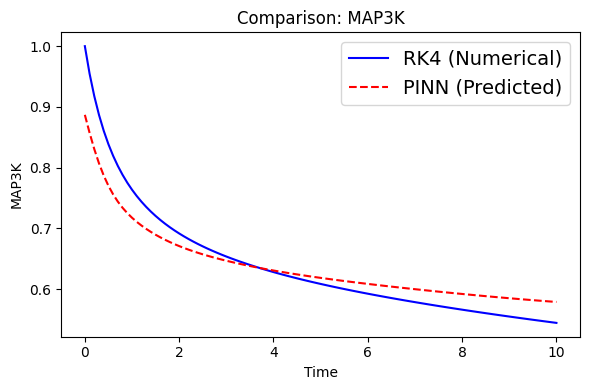

In [13]:
import matplotlib.pyplot as plt
import os
import re

# Labels for variables
labels = ['ATP', 'P2X7', 'P2X7*', 'Ca_cyt', 'Ca_ext',
          'MAP3K', 'MAP3K*', 'JNK', 'JNK*', 'cJun', 'cJun*', 'PTC']

# Create output directory
os.makedirs("results", exist_ok=True)

# Function to make filenames safe
def safe_filename(name):
    return re.sub(r'[^a-zA-Z0-9_]', "_", name)

# Plot and save each variable
for i in range(5,6):
    plt.figure(figsize=(6,4))
    plt.plot(t_rk4, y_rk4[:, i], 'b-', label="RK4 (Numerical)")
    plt.plot(t_test.numpy(), y_pinn[:, i], 'r--', label="PINN (Predicted)")
    plt.xlabel("Time")
    plt.ylabel(labels[i])
    plt.title(f"Comparison: {labels[i]}")
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.style.use("default")   # reset to default (white background)
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.facecolor"] = "white"
    # Save the figure locally
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
file_path = os.path.join(downloads_path, "comp Simulation6 GRAPH.jpg")
plt.savefig(file_path, dpi=300)
print(f"Image saved to: {file_path}")

In [14]:
    # MAE for each variable
mae_per_var = []
for i in range(5,6):
    mae = mean_absolute_error(y_rk4[:, i], y_pinn[:, i])
    mae_per_var.append(mae)
    print(f"MAE for {labels[i]}: {mae:.6f}")

MAE for MAP3K: 0.024635


Image saved to: C:\Users\E-TEC\Downloads\comp Simulation7 GRAPH.jpg


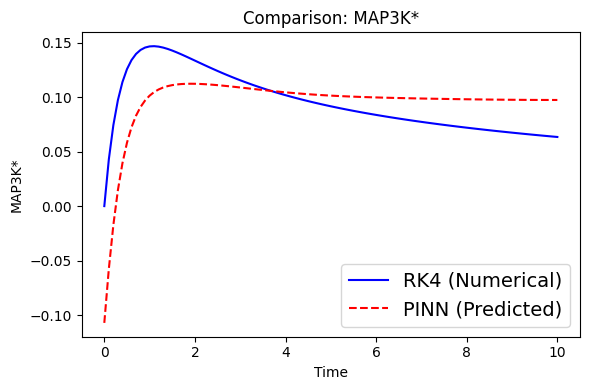

In [15]:
import matplotlib.pyplot as plt
import os
import re

# Labels for variables
labels = ['ATP', 'P2X7', 'P2X7*', 'Ca_cyt', 'Ca_ext',
          'MAP3K', 'MAP3K*', 'JNK', 'JNK*', 'cJun', 'cJun*', 'PTC']

# Create output directory
os.makedirs("results", exist_ok=True)

# Function to make filenames safe
def safe_filename(name):
    return re.sub(r'[^a-zA-Z0-9_]', "_", name)

# Plot and save each variable
for i in range(6,7):
    plt.figure(figsize=(6,4))
    plt.plot(t_rk4, y_rk4[:, i], 'b-', label="RK4 (Numerical)")
    plt.plot(t_test.numpy(), y_pinn[:, i], 'r--', label="PINN (Predicted)")
    plt.xlabel("Time")
    plt.ylabel(labels[i])
    plt.title(f"Comparison: {labels[i]}")
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.style.use("default")   # reset to default (white background)
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.facecolor"] = "white"
    # Save the figure locally
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
file_path = os.path.join(downloads_path, "comp Simulation7 GRAPH.jpg")
plt.savefig(file_path, dpi=300)
print(f"Image saved to: {file_path}")

In [16]:
    # MAE for each variable
mae_per_var = []
for i in range(6,7):
    mae = mean_absolute_error(y_rk4[:, i], y_pinn[:, i])
    mae_per_var.append(mae)
    print(f"MAE for {labels[i]}: {mae:.6f}")

MAE for MAP3K*: 0.024622


Image saved to: C:\Users\E-TEC\Downloads\comp Simulation8 GRAPH.jpg


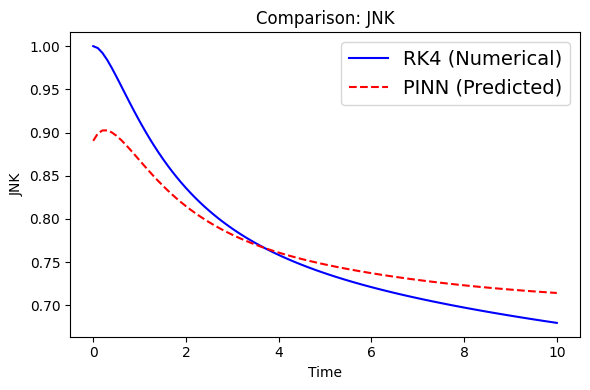

In [17]:
import matplotlib.pyplot as plt
import os
import re

# Labels for variables
labels = ['ATP', 'P2X7', 'P2X7*', 'Ca_cyt', 'Ca_ext',
          'MAP3K', 'MAP3K*', 'JNK', 'JNK*', 'cJun', 'cJun*', 'PTC']

# Create output directory
os.makedirs("results", exist_ok=True)

# Function to make filenames safe
def safe_filename(name):
    return re.sub(r'[^a-zA-Z0-9_]', "_", name)

# Plot and save each variable
for i in range(7,8):
    plt.figure(figsize=(6,4))
    plt.plot(t_rk4, y_rk4[:, i], 'b-', label="RK4 (Numerical)")
    plt.plot(t_test.numpy(), y_pinn[:, i], 'r--', label="PINN (Predicted)")
    plt.xlabel("Time")
    plt.ylabel(labels[i])
    plt.title(f"Comparison: {labels[i]}")
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.style.use("default")   # reset to default (white background)
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.facecolor"] = "white"
    # Save the figure locally
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
file_path = os.path.join(downloads_path, "comp Simulation8 GRAPH.jpg")
plt.savefig(file_path, dpi=300)
print(f"Image saved to: {file_path}")

In [18]:
    # MAE for each variable
mae_per_var = []
for i in range(7,8):
    mae = mean_absolute_error(y_rk4[:, i], y_pinn[:, i])
    mae_per_var.append(mae)
    print(f"MAE for {labels[i]}: {mae:.6f}")

MAE for JNK: 0.024670


Image saved to: C:\Users\E-TEC\Downloads\comp Simulation9 GRAPH.jpg


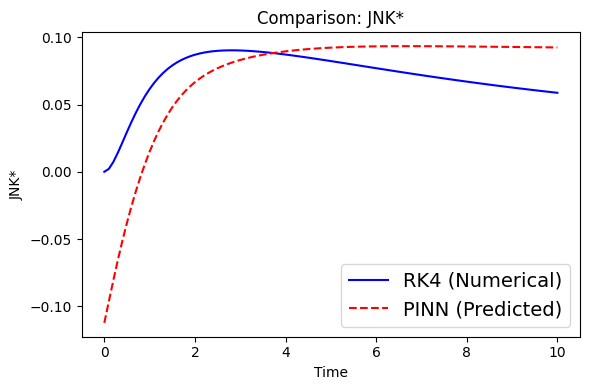

In [19]:
import matplotlib.pyplot as plt
import os
import re

# Labels for variables
labels = ['ATP', 'P2X7', 'P2X7*', 'Ca_cyt', 'Ca_ext',
          'MAP3K', 'MAP3K*', 'JNK', 'JNK*', 'cJun', 'cJun*', 'PTC']

# Create output directory
os.makedirs("results", exist_ok=True)

# Function to make filenames safe
def safe_filename(name):
    return re.sub(r'[^a-zA-Z0-9_]', "_", name)

# Plot and save each variable
for i in range(8,9):
    plt.figure(figsize=(6,4))
    plt.plot(t_rk4, y_rk4[:, i], 'b-', label="RK4 (Numerical)")
    plt.plot(t_test.numpy(), y_pinn[:, i], 'r--', label="PINN (Predicted)")
    plt.xlabel("Time")
    plt.ylabel(labels[i])
    plt.title(f"Comparison: {labels[i]}")
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.style.use("default")   # reset to default (white background)
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.facecolor"] = "white"
    # Save the figure locally
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
file_path = os.path.join(downloads_path, "comp Simulation9 GRAPH.jpg")
plt.savefig(file_path, dpi=300)
print(f"Image saved to: {file_path}")

In [20]:
    # MAE for each variable
mae_per_var = []
for i in range(8,9):
    mae = mean_absolute_error(y_rk4[:, i], y_pinn[:, i])
    mae_per_var.append(mae)
    print(f"MAE for {labels[i]}: {mae:.6f}")

MAE for JNK*: 0.024647


Image saved to: C:\Users\E-TEC\Downloads\comp Simulation10 GRAPH.jpg


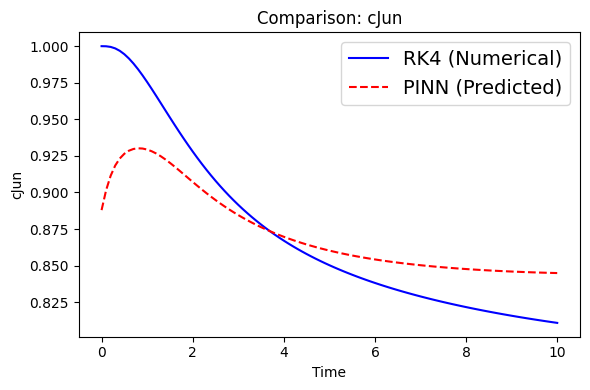

In [21]:
import matplotlib.pyplot as plt
import os
import re

# Labels for variables
labels = ['ATP', 'P2X7', 'P2X7*', 'Ca_cyt', 'Ca_ext',
          'MAP3K', 'MAP3K*', 'JNK', 'JNK*', 'cJun', 'cJun*', 'PTC']

# Create output directory
os.makedirs("results", exist_ok=True)

# Function to make filenames safe
def safe_filename(name):
    return re.sub(r'[^a-zA-Z0-9_]', "_", name)

# Plot and save each variable
for i in range(9,10):
    plt.figure(figsize=(6,4))
    plt.plot(t_rk4, y_rk4[:, i], 'b-', label="RK4 (Numerical)")
    plt.plot(t_test.numpy(), y_pinn[:, i], 'r--', label="PINN (Predicted)")
    plt.xlabel("Time")
    plt.ylabel(labels[i])
    plt.title(f"Comparison: {labels[i]}")
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.style.use("default")   # reset to default (white background)
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.facecolor"] = "white"
    # Save the figure locally
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
file_path = os.path.join(downloads_path, "comp Simulation10 GRAPH.jpg")
plt.savefig(file_path, dpi=300)
print(f"Image saved to: {file_path}")

In [22]:
    # MAE for each variable
mae_per_var = []
for i in range(9,10):
    mae = mean_absolute_error(y_rk4[:, i], y_pinn[:, i])
    mae_per_var.append(mae)
    print(f"MAE for {labels[i]}: {mae:.6f}")

MAE for cJun: 0.024645


Image saved to: C:\Users\E-TEC\Downloads\comp Simulation11 GRAPH.jpg


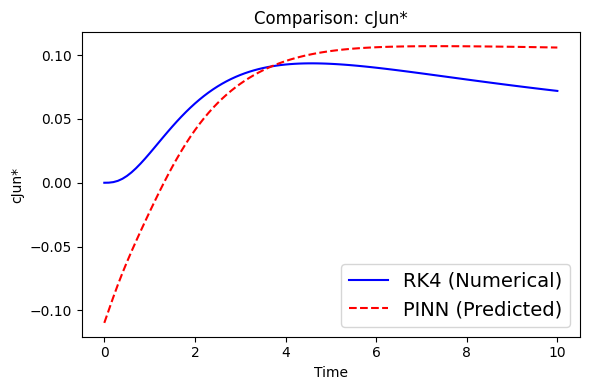

In [23]:
import matplotlib.pyplot as plt
import os
import re

# Labels for variables
labels = ['ATP', 'P2X7', 'P2X7*', 'Ca_cyt', 'Ca_ext',
          'MAP3K', 'MAP3K*', 'JNK', 'JNK*', 'cJun', 'cJun*', 'PTC']

# Create output directory
os.makedirs("results", exist_ok=True)

# Function to make filenames safe
def safe_filename(name):
    return re.sub(r'[^a-zA-Z0-9_]', "_", name)

# Plot and save each variable
for i in range(10,11):
    plt.figure(figsize=(6,4))
    plt.plot(t_rk4, y_rk4[:, i], 'b-', label="RK4 (Numerical)")
    plt.plot(t_test.numpy(), y_pinn[:, i], 'r--', label="PINN (Predicted)")
    plt.xlabel("Time")
    plt.ylabel(labels[i])
    plt.title(f"Comparison: {labels[i]}")
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.style.use("default")   # reset to default (white background)
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.facecolor"] = "white"
    # Save the figure locally
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
file_path = os.path.join(downloads_path, "comp Simulation11 GRAPH.jpg")
plt.savefig(file_path, dpi=300)
print(f"Image saved to: {file_path}")

In [24]:
    # MAE for each variable
mae_per_var = []
for i in range(10,11):
    mae = mean_absolute_error(y_rk4[:, i], y_pinn[:, i])
    mae_per_var.append(mae)
    print(f"MAE for {labels[i]}: {mae:.6f}")

MAE for cJun*: 0.024651


Image saved to: C:\Users\E-TEC\Downloads\comp Simulation12 GRAPH.jpg


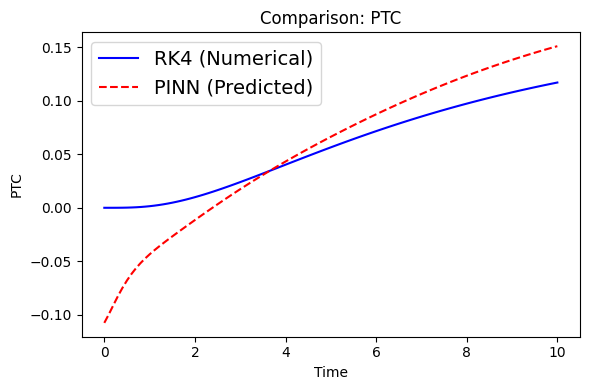

In [25]:
import matplotlib.pyplot as plt
import os
import re

# Labels for variables
labels = ['ATP', 'P2X7', 'P2X7*', 'Ca_cyt', 'Ca_ext',
          'MAP3K', 'MAP3K*', 'JNK', 'JNK*', 'cJun', 'cJun*', 'PTC']

# Create output directory
os.makedirs("results", exist_ok=True)

# Function to make filenames safe
def safe_filename(name):
    return re.sub(r'[^a-zA-Z0-9_]', "_", name)

# Plot and save each variable
for i in range(11,12):
    plt.figure(figsize=(6,4))
    plt.plot(t_rk4, y_rk4[:, i], 'b-', label="RK4 (Numerical)")
    plt.plot(t_test.numpy(), y_pinn[:, i], 'r--', label="PINN (Predicted)")
    plt.xlabel("Time")
    plt.ylabel(labels[i])
    plt.title(f"Comparison: {labels[i]}")
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.style.use("default")   # reset to default (white background)
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.facecolor"] = "white"
    # Save the figure locally
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
file_path = os.path.join(downloads_path, "comp Simulation12 GRAPH.jpg")
plt.savefig(file_path, dpi=300)
print(f"Image saved to: {file_path}")

In [26]:
    # MAE for each variable
mae_per_var = []
for i in range(11,12):
    mae = mean_absolute_error(y_rk4[:, i], y_pinn[:, i])
    mae_per_var.append(mae)
    print(f"MAE for {labels[i]}: {mae:.6f}")

MAE for PTC: 0.024627
